In [11]:
import yaml
from omegaconf import DictConfig, OmegaConf
import os
# from trainer import Trainer
# OmegaConf.register_new_resolver("eval", eval)

In [12]:
config_path = "/home/monsh/works/image/madx/config/test.yaml"
root_dir = "/home/monsh/works/image/madx"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# with open(os.path.join(root_dir, "config", "agent", "default.yaml"), "r") as f:
#     agent_config = yaml.safe_load(f)

# with open(os.path.join(root_dir, "config", "env", "atari.yaml"), "r") as f:
#     env_config = yaml.safe_load(f)
#     env_config['train']['id'] = "BoxingNoFrameskip-v4"

# config['defaults'][1]['env'] = env_config
# config['defaults'][2]['agent'] = agent_config

In [13]:
from functools import partial
from pathlib import Path
import shutil
import time
from typing import List, Optional, Tuple

from hydra.utils import instantiate
import numpy as np
from omegaconf import DictConfig, OmegaConf
import torch
import torch.distributed as dist
from torch.utils.data import DataLoader
from tqdm import tqdm, trange
import wandb

from agent import Agent
from coroutines.collector import make_collector, NumToCollect
from data import BatchSampler, collate_segments_to_batch, Dataset, DatasetTraverser
from envs import make_atari_env, WorldModelEnv
from utils import (
    broadcast_if_needed,
    build_ddp_wrapper,
    CommonTools,
    configure_opt,
    count_parameters,
    get_lr_sched,
    keep_agent_copies_every,
    Logs,
    process_confusion_matrices_if_any_and_compute_classification_metrics,
    save_info_for_import_script,
    save_with_backup,
    set_seed,
    StateDictMixin,
    try_until_no_except,
    wandb_log,
)


class Trainer(StateDictMixin):
    def __init__(self, cfg: DictConfig, root_dir: Path) -> None:
        torch.backends.cuda.matmul.allow_tf32 = True
        OmegaConf.resolve(cfg)
        self._cfg = cfg
        self._rank = dist.get_rank() if dist.is_initialized() else 0
        self._world_size = dist.get_world_size() if dist.is_initialized() else 1

        # Pick a random seed
        set_seed(torch.seed() % 10**9)

        # Device
        self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu", self._rank)
        print(f"Starting on {self._device}")
        self._use_cuda = self._device.type == "cuda"
        if self._use_cuda:
            torch.cuda.set_device(self._rank)  # fix compilation error on multi-gpu nodes

        # Init wandb
        if self._rank == 0:
            try_until_no_except(
                partial(wandb.init, config=OmegaConf.to_container(cfg, resolve=True), reinit=True, resume=True, **cfg.wandb)
            )

        # Flags
        self._is_static_dataset = cfg.static_dataset.path is not None
        self._is_model_free = cfg.training.model_free

        # Checkpointing
        self._path_ckpt_dir = Path("checkpoints")
        self._path_state_ckpt = self._path_ckpt_dir / "state.pt"
        self._keep_agent_copies = partial(
            keep_agent_copies_every,
            every=cfg.checkpointing.save_agent_every,
            path_ckpt_dir=self._path_ckpt_dir,
            num_to_keep=cfg.checkpointing.num_to_keep,
        )
        self._save_info_for_import_script = partial(save_info_for_import_script, run_name=cfg.wandb.name, path_ckpt_dir=self._path_ckpt_dir)

        # First time, init files hierarchy
        if not cfg.common.resume and self._rank == 0:
            self._path_ckpt_dir.mkdir(exist_ok=False, parents=False)
            path_config = Path("config") / "trainer.yaml"
            path_config.parent.mkdir(exist_ok=False, parents=False)
            # shutil.move(".hydra/config.yaml", path_config)
            # wandb.save(str(path_config))
            # shutil.copytree(src=root_dir / "src", dst="./src")
            # shutil.copytree(src=root_dir / "scripts", dst="./scripts")

        # Datasets
        num_workers = cfg.training.num_workers_data_loaders
        use_manager = cfg.training.cache_in_ram and (num_workers > 0)
        p = Path(cfg.static_dataset.path) if self._is_static_dataset else Path("dataset")
        self.train_dataset = Dataset(p / "train", "train_dataset", cfg.training.cache_in_ram, use_manager)
        self.test_dataset = Dataset(p / "test", "test_dataset", cache_in_ram=True)
        self.train_dataset.load_from_default_path()
        self.test_dataset.load_from_default_path()

        # Envs
        if self._rank == 0:
            train_env = make_atari_env(num_envs=cfg.collection.train.num_envs, device=self._device, **cfg.env.train)
            test_env = make_atari_env(num_envs=cfg.collection.test.num_envs, device=self._device, **cfg.env.test)
            num_actions = int(test_env.num_actions)
        else:
            num_actions = None
        (num_actions,) = broadcast_if_needed(num_actions)

        # Create models
        self.agent = Agent(instantiate(cfg.agent, num_actions=num_actions)).to(self._device)
        self._agent = build_ddp_wrapper(**self.agent._modules) if dist.is_initialized() else self.agent

        if cfg.initialization.path_to_ckpt is not None:
            self.agent.load(**cfg.initialization)

        # Collectors
        if not self._is_static_dataset and self._rank == 0:
            self._train_collector = make_collector(train_env, self.agent.actor_critic, self.train_dataset, cfg.collection.train.epsilon)
            self._test_collector = make_collector(
                test_env, self.agent.actor_critic, self.test_dataset, cfg.collection.test.epsilon, reset_every_collect=True
            )

        # print(self._train_collector)
        # return

        ######################################################

        # Optimizers and LR schedulers

        def build_opt(name: str) -> torch.optim.AdamW:
            return configure_opt(getattr(self.agent, name), **getattr(cfg, name).optimizer)

        def build_lr_sched(name: str) -> torch.optim.lr_scheduler.LambdaLR:
            return get_lr_sched(self.opt.get(name), getattr(cfg, name).training.lr_warmup_steps)

        self._model_names = ["denoiser", "rew_end_model", "actor_critic"]
        self.opt = CommonTools(*map(build_opt, self._model_names))
        self.lr_sched = CommonTools(*map(build_lr_sched, self._model_names))

        # Data loaders

        make_data_loader = partial(
            DataLoader,
            dataset=self.train_dataset,
            collate_fn=collate_segments_to_batch,
            num_workers=num_workers,
            persistent_workers=(num_workers > 0),
            pin_memory=self._use_cuda,
            pin_memory_device=str(self._device) if self._use_cuda else "",
        )

        make_batch_sampler = partial(BatchSampler, self.train_dataset, self._rank, self._world_size)

        def get_sample_weights(sample_weights: List[float]) -> Optional[List[float]]:
            return None if (self._is_static_dataset and cfg.static_dataset.ignore_sample_weights) else sample_weights

        c = cfg.denoiser.training
        seq_length = cfg.agent.denoiser.inner_model.num_steps_conditioning + 1 + c.num_autoregressive_steps
        bs = make_batch_sampler(c.batch_size, seq_length, get_sample_weights(c.sample_weights))
        dl_denoiser_train = make_data_loader(batch_sampler=bs)
        dl_denoiser_test = DatasetTraverser(self.test_dataset, c.batch_size, seq_length)

        c = cfg.rew_end_model.training
        bs = make_batch_sampler(c.batch_size, c.seq_length, get_sample_weights(c.sample_weights), can_sample_beyond_end=True)
        dl_rew_end_model_train = make_data_loader(batch_sampler=bs)
        dl_rew_end_model_test = DatasetTraverser(self.test_dataset, c.batch_size, c.seq_length)

        self._data_loader_train = CommonTools(dl_denoiser_train, dl_rew_end_model_train, None)
        self._data_loader_test = CommonTools(dl_denoiser_test, dl_rew_end_model_test, None)

        # RL env

        if self._is_model_free:
            rl_env = make_atari_env(num_envs=cfg.actor_critic.training.batch_size, device=self._device, **cfg.env.train)

        else:
            c = cfg.actor_critic.training
            sl = cfg.agent.denoiser.inner_model.num_steps_conditioning
            bs = make_batch_sampler(c.batch_size, sl, get_sample_weights(c.sample_weights))
            dl_actor_critic = make_data_loader(batch_sampler=bs)
            wm_env_cfg = instantiate(cfg.world_model_env)
            rl_env = WorldModelEnv(self.agent.denoiser, self.agent.rew_end_model, dl_actor_critic, wm_env_cfg)

            if cfg.training.compile_wm:
                rl_env.predict_next_obs = torch.compile(rl_env.predict_next_obs, mode="reduce-overhead")
                rl_env.predict_rew_end = torch.compile(rl_env.predict_rew_end, mode="reduce-overhead")

        # Setup training
        sigma_distribution_cfg = instantiate(cfg.denoiser.sigma_distribution)
        actor_critic_loss_cfg = instantiate(cfg.actor_critic.actor_critic_loss)
        self.agent.setup_training(sigma_distribution_cfg, actor_critic_loss_cfg, rl_env)

        # Training state (things to be saved/restored)
        self.epoch = 0
        self.num_epochs_collect = None
        self.num_episodes_test = 0
        self.num_batch_train = CommonTools(0, 0, 0)
        self.num_batch_test = CommonTools(0, 0, 0)

        if cfg.common.resume:
            self.load_state_checkpoint()
        else:
            self.save_checkpoint()

        if self._rank == 0:
            for name in self._model_names:
                print(f"{count_parameters(getattr(self.agent, name))} parameters in {name}")
            print(self.train_dataset)
            print(self.test_dataset)

    def run(self) -> None:
        to_log = []

        if self.epoch == 0:
            if self._is_model_free or self._is_static_dataset:
                self.num_epochs_collect = 0
            else:
                if self._rank == 0:
                    self.num_epochs_collect, to_log_ = self.collect_initial_dataset()
                    to_log += to_log_
                self.num_epochs_collect, sd_train_dataset = broadcast_if_needed(self.num_epochs_collect, self.train_dataset.state_dict())
                self.train_dataset.load_state_dict(sd_train_dataset)

        num_epochs = self.num_epochs_collect + self._cfg.training.num_final_epochs

        while self.epoch < num_epochs:
            self.epoch += 1
            start_time = time.time()

            if self._rank == 0:
                print(f"\nEpoch {self.epoch} / {num_epochs}\n")

            # Training
            should_collect_train = (
                self._rank == 0 and not self._is_model_free and not self._is_static_dataset and self.epoch <= self.num_epochs_collect
            )

            if should_collect_train:
                c = self._cfg.collection.train
                to_log += self._train_collector.send(NumToCollect(steps=c.steps_per_epoch))
            (sd_train_dataset,) = broadcast_if_needed(self.train_dataset.state_dict())  # update dataset for ranks > 0
            self.train_dataset.load_state_dict(sd_train_dataset)  # Load dataset from episodes and steps

            if self._cfg.training.should:
                to_log += self.train_agent()

            # Evaluation
            should_test = self._rank == 0 and self._cfg.evaluation.should and (self.epoch % self._cfg.evaluation.every == 0)
            should_collect_test = should_test and not self._is_static_dataset

            if should_collect_test:
                to_log += self.collect_test()

            if should_test and not self._is_model_free:
                to_log += self.test_agent()

            # Logging
            to_log.append({"duration": (time.time() - start_time) / 3600})
            if self._rank == 0:
                wandb_log(to_log, self.epoch)
            to_log = []

            # Checkpointing
            self.save_checkpoint()

            if dist.is_initialized():
                dist.barrier()

        # Last collect
        if self._rank == 0 and not self._is_static_dataset:
            wandb_log(self.collect_test(final=True), self.epoch)

    def collect_initial_dataset(self) -> Tuple[int, Logs]:
        print("\nInitial collect\n")
        to_log = []
        c = self._cfg.collection.train
        min_steps = c.first_epoch.min
        steps_per_epoch = c.steps_per_epoch
        max_steps = c.first_epoch.max
        threshold_rew = c.first_epoch.threshold_rew
        assert min_steps % steps_per_epoch == 0

        steps = min_steps
        while True:
            to_log += self._train_collector.send(NumToCollect(steps=steps))
            num_steps = self.train_dataset.num_steps
            total_minority_rew = sum(sorted(self.train_dataset.counts_rew)[:-1])
            if total_minority_rew >= threshold_rew:
                break
            if (max_steps is not None) and num_steps >= max_steps:
                print("Reached the specified maximum for initial collect")
                break
            print(f"Minority reward: {total_minority_rew}/{threshold_rew} -> Keep collecting\n")
            steps = steps_per_epoch

        print("\nSummary of initial collect:")
        print(f"Num steps: {num_steps} / {c.num_steps_total}")
        print(f"Reward counts: {dict(self.train_dataset.counter_rew)}")

        remaining_steps = c.num_steps_total - num_steps
        assert remaining_steps % c.steps_per_epoch == 0
        num_epochs_collect = remaining_steps // c.steps_per_epoch

        return num_epochs_collect, to_log

    def collect_test(self, final: bool = False) -> Logs:
        c = self._cfg.collection.test
        episodes = c.num_final_episodes if final else c.num_episodes
        td = self.test_dataset
        td.clear()
        to_log = self._test_collector.send(NumToCollect(episodes=episodes))
        key_ep_id = f"{td.name}/episode_id"
        to_log = [{k: v + self.num_episodes_test if k == key_ep_id else v for k, v in x.items()} for x in to_log]

        print(f"\nSummary of {'final' if final else 'test'} collect: {td.num_episodes} episodes ({td.num_steps} steps)")
        keys = [key_ep_id, "return", "length"]
        to_log_episodes = [x for x in to_log if set(x.keys()) == set(keys)]
        episode_ids, returns, lengths = [[d[k] for d in to_log_episodes] for k in keys]
        for i, (ep_id, ret, length) in enumerate(zip(episode_ids, returns, lengths)):
            print(f"  Episode {ep_id}: return = {ret} length = {length}\n", end="\n" if i == episodes - 1 else "")

        self.num_episodes_test += episodes

        if final:
            to_log.append({"final_return_mean": np.mean(returns), "final_return_std": np.std(returns)})
            print(to_log[-1])

        return to_log

    def train_agent(self) -> Logs:
        self.agent.train()
        self.agent.zero_grad()
        to_log = []
        model_names = ["actor_critic"] if self._is_model_free else self._model_names
        for name in model_names:
            cfg = getattr(self._cfg, name).training
            if self.epoch > cfg.start_after_epochs:
                steps = cfg.steps_first_epoch if self.epoch == 1 else cfg.steps_per_epoch
                to_log += self.train_component(name, steps)
        return to_log

    @torch.no_grad()
    def test_agent(self) -> Logs:
        self.agent.eval()
        to_log = []
        model_names = [] if self._is_model_free else self._model_names[:-1]
        for name in model_names:
            cfg = getattr(self._cfg, name).training
            if self.epoch > cfg.start_after_epochs:
                to_log += self.test_component(name)
        return to_log

    def train_component(self, name: str, steps: int) -> Logs:
        cfg = getattr(self._cfg, name).training
        model = getattr(self._agent, name)
        opt = self.opt.get(name)
        lr_sched = self.lr_sched.get(name)
        data_loader = self._data_loader_train.get(name)

        model.train()
        opt.zero_grad()
        data_iterator = iter(data_loader) if data_loader is not None else None
        to_log = []

        num_steps = cfg.grad_acc_steps * steps

        for i in trange(num_steps, desc=f"Training {name}", disable=self._rank > 0):
            batch = next(data_iterator).to(self._device) if data_iterator is not None else None
            # print(batch)
            self.batch_iter = batch
            loss, metrics = model(batch) if batch is not None else model()
            loss.backward()

            num_batch = self.num_batch_train.get(name)
            metrics[f"num_batch_train_{name}"] = num_batch
            self.num_batch_train.set(name, num_batch + 1)
            print(self._cfg)
            if (i + 1) % cfg.grad_acc_steps == 0:
                if cfg.max_grad_norm is not None:
                    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                    metrics["grad_norm_before_clip"] = grad_norm

                opt.step()
                opt.zero_grad()

                if lr_sched is not None:
                    metrics["lr"] = lr_sched.get_last_lr()[0]
                    lr_sched.step()

            to_log.append(metrics)

        process_confusion_matrices_if_any_and_compute_classification_metrics(to_log)
        to_log = [{f"{name}/train/{k}": v for k, v in d.items()} for d in to_log]
        return to_log

    @torch.no_grad()
    def test_component(self, name: str) -> Logs:
        model = getattr(self.agent, name)
        data_loader = self._data_loader_test.get(name)
        model.eval()
        to_log = []
        for batch in tqdm(data_loader, desc=f"Evaluating {name}"):
            batch = batch.to(self._device)
            _, metrics = model(batch)
            num_batch = self.num_batch_test.get(name)
            metrics[f"num_batch_test_{name}"] = num_batch
            self.num_batch_test.set(name, num_batch + 1)
            to_log.append(metrics)

        process_confusion_matrices_if_any_and_compute_classification_metrics(to_log)
        to_log = [{f"{name}/test/{k}": v for k, v in d.items()} for d in to_log]
        return to_log

    def load_state_checkpoint(self) -> None:
        self.load_state_dict(torch.load(self._path_state_ckpt, map_location=self._device))

    def save_checkpoint(self) -> None:
        if self._rank == 0:
            save_with_backup(self.state_dict(), self._path_state_ckpt)
            self.train_dataset.save_to_default_path()
            self.test_dataset.save_to_default_path()
            self._keep_agent_copies(self.agent.state_dict(), self.epoch)
            self._save_info_for_import_script(self.epoch)


In [14]:
import shutil

shutil.rmtree("checkpoints", ignore_errors=True)
shutil.rmtree("config", ignore_errors=True)

trainer = Trainer(OmegaConf.structured(config), "/home/monsh/works/image/madx/")
trainer.run()

Starting on cuda:0


/home/monsh/works/image/madx/src/data/dataset.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self._default_path))
/home/monsh/anaconda

4406851 parameters in denoiser
5902656 parameters in rew_end_model
3236819 parameters in actor_critic
train_dataset: 0 episodes, 0 steps.
test_dataset: 0 episodes, 0 steps.

Initial collect



Collect train_dataset: 100%|██████████| 5000/5000 [00:31<00:00, 157.01steps/s]



Summary of initial collect:
Num steps: 5000 / 100000
Reward counts: {0.0: 4843, 1.0: 72, -1.0: 85}

Epoch 1 / 1000



...

Training denoiser:   0%|          | 3/10000 [00:00<43:45,  3.81it/s]  

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True], device='cuda:0')
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True], device='cuda:0')
{'wandb': {'mode': 'disabled', 'project': None, 'entity': None, 'name': None, 'group': None, 'tags': None, 'notes': None}, 'initialization': {'path_to_ckpt': None, 'load_denoiser': True, 'load_rew_end_model': True, 'load_actor_critic': True}, 'common': {'devices': 0, 'seed': None, 'resume': False}, 'checkpointing': {'save_agent_every': 5, 'num_to_keep': 11}, 'collection': {'train': {'num_envs': 1, 'epsilon': 0.01, 'num_steps_total': 100000, 'first_epoch': {'min': 5000, 'max': 10000, 'threshold_rew': 10}, 'steps_per_epoch': 100

Training denoiser:   0%|          | 3/10000 [00:00<51:13,  3.25it/s]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True], device='cuda:0')


KeyboardInterrupt: 

In [9]:
"common" in (""""\n{'wandb': {'mode': 'disabled', 'project': None, 'entity': None, 'name': None, 'group': None, 'tags': None, 'notes': None}, 'initialization': {'path_to_ckpt': None, 'load_denoiser': True, 'load_rew_end_model': True, 'load_actor_critic': True}, 'common': {'devices': 0, 'seed': None, 'resume': False}, 'checkpointing': {'save_agent_every': 5, 'num_to_keep': 11}, 'collection': {'train': {'num_envs': 1, 'epsilon': 0.01, 'num_steps_total': 100000, 'first_epoch': {'min': 5000, 'max': 10000, 'threshold_rew': 10}, 'steps_per_epoch': 100}, 'test': {'num_envs': 1, 'num_episodes': 4, 'epsilon': 0.0, 'num_final_episodes': 100}}, 'static_dataset': {'path': None, 'ignore_sample_weights': True}, 'training': {'should': True, 'num_final_epochs': 50, 'cache_in_ram': True, 'num_workers_data_loaders': 0, 'model_free': False, 'compile_wm': True}, 'evaluation': {'should': True, 'every': 10}, 'world_model_env': {'_target_': 'envs.WorldModelEnvConfig', 'horizon': 15, 'num_batches_to_preload': 256, 'diffusion_sampler': {'_target_': 'models.diffusion.DiffusionSamplerConfig', 'num_steps_denoising': 3, 'sigma_min': 0.002, 'sigma_max': 5.0, 'rho': 7, 'order': 1, 's_churn': 0.0, 's_tmin': 0.0, 's_tmax': inf, 's_noise': 1.0}}, 'denoiser': {'training': {'num_autoregressive_steps': 1, 'start_after_epochs': 0, 'steps_first_epoch': 10000, 'steps_per_epoch': 400, 'sample_weights': [0.1, 0.1, 0.1, 0.7], 'batch_size': 32, 'grad_acc_steps': 1, 'lr_warmup_steps': 100, 'max_grad_norm': 1.0}, 'optimizer': {'lr': 0.0001, 'weight_decay': 0.01, 'eps': 1e-08}, 'sigma_distribution': {'_target_': 'models.diffusion.SigmaDistributionConfig', 'loc': -0.4, 'scale': 1.2, 'sigma_min': 0.002, 'sigma_max': 20}}, 'rew_end_model': {'training': {'seq_length': 19, 'start_after_epochs': 0, 'steps_first_epoch': 10000, 'steps_per_epoch': 400, 'sample_weights': [0.1, 0.1, 0.1, 0.7], 'batch_size': 32, 'grad_acc_steps': 1, 'lr_warmup_steps': 100, 'max_grad_norm': 100.0}, 'optimizer': {'lr': 0.0001, 'weight_decay': 0.01, 'eps': 1e-08}}, 'actor_critic': {'training': {'sample_weights': [0.1, 0.1, 0.1, 0.7], 'batch_size': 32, 'grad_acc_steps': 1, 'start_after_epochs': 0, 'steps_first_epoch': 5000, 'steps_per_epoch': 400, 'lr_warmup_steps': 100, 'max_grad_norm': 100.0}, 'actor_critic_loss': {'_target_': 'models.actor_critic.ActorCriticLossConfig', 'backup_every': 15, 'gamma': 0.985, 'lambda_': 0.95, 'weight_value_loss': 1.0, 'weight_entropy_loss': 0.001}, 'optimizer': {'lr': 0.0001, 'weight_decay': 0, 'eps': 1e-08}}, 'env': {'train': {'id': 'BoxingNoFrameskip-v4', 'done_on_life_loss': True, 'size': 64, 'max_episode_steps': None}, 'test': {'id': 'BoxingNoFrameskip-v4', 'done_on_life_loss': False, 'size': 64, 'max_episode_steps': None}, 'keymap': 'atari/BoxingNoFrameskip-v4'}, 'agent': {'_target_': 'agent.AgentConfig', 'denoiser': {'_target_': 'models.diffusion.DenoiserConfig', 'sigma_data': 0.5, 'sigma_offset_noise': 0.3, 'inner_model': {'_target_': 'models.diffusion.InnerModelConfig', 'img_channels': 3, 'num_steps_conditioning': 4, 'cond_channels': 256, 'depths': [2, 2, 2, 2], 'channels': [64, 64, 64, 64], 'attn_depths': [0, 0, 0, 0]}}, 'rew_end_model': {'_target_': 'models.rew_end_model.RewEndModelConfig', 'lstm_dim': 512, 'img_channels': 3, 'img_size': 64, 'cond_channels': 128, 'depths': [2, 2, 2, 2], 'channels': [32, 32, 32, 32], 'attn_depths': [0, 0, 0, 0]}, 'actor_critic': {'_target_': 'models.actor_critic.ActorCriticConfig', 'lstm_dim': 512, 'img_channels': 3, 'img_size': 64, 'channels': [32, 32, 64, 64], 'down': [1, 1, 1, 1]}}}\n\n""")


True

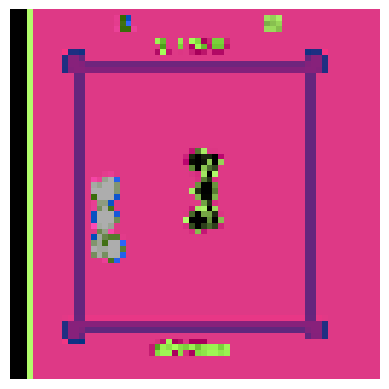

In [ ]:
# trainer.batch_iter.obs[0][0] 

# torch to numpy image
def torch_to_numpy(image):
    image = image.cpu().numpy()
    image = np.transpose(image, (1, 2, 0))  # Change from (C, H, W) to (H, W, C)
    image = (image * 255).astype(np.uint8)  # Convert to uint8
    return image

import matplotlib.pyplot as plt

plt.imshow(torch_to_numpy(trainer.batch_iter.obs[0][4]))
plt.axis('off')  # Hide the axes
plt.show()





In [39]:
from __future__ import annotations

from typing import Any, SupportsFloat

import cv2
import numpy as np

import gymnasium as gym
from gymnasium.core import WrapperActType, WrapperObsType
from gymnasium.spaces import Box


class AtariPreprocessing(gym.Wrapper, gym.utils.RecordConstructorArgs):
    def __init__(
        self,
        env: gym.Env,
        noop_max: int,
        frame_skip: int,
        screen_size: int,
    ):
        gym.utils.RecordConstructorArgs.__init__(
            self,
            noop_max=noop_max,
            frame_skip=frame_skip,
            screen_size=screen_size,
        )
        gym.Wrapper.__init__(self, env)

        assert frame_skip > 0
        assert screen_size > 0
        assert noop_max >= 0
        if frame_skip > 1 and getattr(env.unwrapped, "_frameskip", None) != 1:
            raise ValueError(
                "Disable frame-skipping in the original env. Otherwise, more than one frame-skip will happen as through this wrapper"
            )
        self.noop_max = noop_max
        assert env.unwrapped.get_action_meanings()[0] == "NOOP"

        self.frame_skip = frame_skip
        self.screen_size = screen_size

        # buffer of most recent two observations for max pooling
        assert isinstance(env.observation_space, Box)
        self.obs_buffer = [
            np.empty(env.observation_space.shape, dtype=np.uint8),
            np.empty(env.observation_space.shape, dtype=np.uint8),
        ]

        self.lives = 0
        self.game_over = False

        _low, _high, _obs_dtype = (0, 255, np.uint8)
        _shape = (screen_size, screen_size, 3)
        self.observation_space = Box(low=_low, high=_high, shape=_shape, dtype=_obs_dtype)

    @property
    def ale(self):
        """Make ale as a class property to avoid serialization error."""
        return self.env.unwrapped.ale

    def step(self, action: WrapperActType) -> tuple[WrapperObsType, SupportsFloat, bool, bool, dict[str, Any]]:
        total_reward, terminated, truncated, info = 0.0, False, False, {}
        life_loss = False

        for t in range(self.frame_skip):
            _, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward
            self.game_over = terminated

            if self.ale.lives() < self.lives:
                life_loss = True
                self.lives = self.ale.lives()

            if terminated or truncated:
                break

            if t == self.frame_skip - 2:
                self.ale.getScreenRGB(self.obs_buffer[1])
            elif t == self.frame_skip - 1:
                self.ale.getScreenRGB(self.obs_buffer[0])

        info["life_loss"] = life_loss

        obs, original_obs = self._get_obs()
        info["original_obs"] = original_obs

        return obs, total_reward, terminated, truncated, info

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None) -> tuple[WrapperObsType, dict[str, Any]]:
        """Resets the environment using preprocessing."""
        # NoopReset
        _, reset_info = self.env.reset(seed=seed, options=options)

        reset_info["life_loss"] = False

        noops = self.env.unwrapped.np_random.integers(1, self.noop_max + 1) if self.noop_max > 0 else 0
        for _ in range(noops):
            _, _, terminated, truncated, step_info = self.env.step(0)
            reset_info.update(step_info)
            if terminated or truncated:
                _, reset_info = self.env.reset(seed=seed, options=options)

        self.lives = self.ale.lives()
        self.ale.getScreenRGB(self.obs_buffer[0])
        self.obs_buffer[1].fill(0)

        obs, original_obs = self._get_obs()
        reset_info["original_obs"] = original_obs

        return obs, reset_info

    def _get_obs(self):
        if self.frame_skip > 1:  # more efficient in-place pooling
            np.maximum(self.obs_buffer[0], self.obs_buffer[1], out=self.obs_buffer[0])

        original_obs = self.obs_buffer[0]
        obs = cv2.resize(
            original_obs,
            (self.screen_size, self.screen_size),
            interpolation=cv2.INTER_AREA,
        )

        obs = np.asarray(obs, dtype=np.uint8)

        return obs, original_obs

from typing import Any, Dict, Optional, Tuple
from gymnasium.vector import AsyncVectorEnv
from torch import Tensor
import gymnasium

class DoneOnLifeLoss(gymnasium.Wrapper):
    def __init__(self, env: AsyncVectorEnv) -> None:
        super().__init__(env)

    def step(self, actions: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
        obs, rew, end, trunc, info = self.env.step(actions)
        life_loss = info["life_loss"]
        if life_loss.any():
            end[life_loss] = True
            info["final_observation"] = obs
        return obs, rew, end, trunc, info


class TorchEnv(gymnasium.Wrapper):
    def __init__(self, env: gymnasium.Env, device: torch.device) -> None:
        super().__init__(env)
        self.device = device
        self.num_envs = env.observation_space.shape[0]
        self.num_actions = env.unwrapped.single_action_space.n
        b, h, w, c = env.observation_space.shape
        self.observation_space = gymnasium.spaces.Box(low=-1, high=1, shape=(b, c, h, w))
        # # Check if we're dealing with a Boxing environment
        # self.is_boxing = any("Boxing" in spec.id for spec in env.unwrapped.specs)

    def reset(self, *args, **kwargs) -> Tuple[Tensor, Dict[str, Any]]:
        obs, info = self.env.reset(*args, **kwargs)
        return self._to_tensor(obs), info

    def step(self, actions: Tensor) -> Tuple[Tensor, Tensor, Tensor, Tensor, Dict[str, Any]]:
        obs, rew, end, trunc, info = self.env.step(actions.cpu().numpy())
        dead = np.logical_or(end, trunc)
        if dead.any():
            info["final_observation"] = self._to_tensor(np.stack(info["final_observation"][dead]))
        obs, rew, end, trunc = (self._to_tensor(x) for x in (obs, rew, end, trunc))
        return obs, rew, end, trunc, info

    def _to_tensor(self, x: Tensor) -> Tensor:
        if x.ndim == 4:
            return torch.tensor(x, device=self.device).div(255).mul(2).sub(1).permute(0, 3, 1, 2).contiguous()
        elif x.dtype is np.dtype("bool"):
            return torch.tensor(x, dtype=torch.uint8, device=self.device)
        else:
            return torch.tensor(x, dtype=torch.float32, device=self.device)


In [77]:
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/AutoROM/roms
	/home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/AutoROM/roms/adventure.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/multi_agent_ale_py/roms/adventure.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/AutoROM/roms/air_raid.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/multi_agent_ale_py/roms/air_raid.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/AutoROM/roms/alien.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/multi_agent_ale_py/roms/alien.bin
Installed /home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/AutoROM/roms/amidar.bin
Installed /home/monsh/anaco

In [89]:
import ale_py
import gymnasium
from gymnasium.vector import AsyncVectorEnv
from pettingzoo.atari import boxing_v2

def env_fn():
    # Create the environment
    # env = gymnasium.make(
    #     "Boxing",
    #     full_action_space=False,
    #     frameskip=1,
    #     render_mode="rgb_array",
    #     max_episode_steps=None,
    # )
    env = boxing_v2.env(render_mode="rgb_array")
    # env = AtariPreprocessing(
    #     env=env,
    #     noop_max=30,
    #     frame_skip=4,
    #     screen_size=64,
    # )
    return env

env = AsyncVectorEnv([env_fn for _ in range(1)])
# env = DoneOnLifeLoss(env)

# env = TorchEnv(env, 'cuda:0')
# env_fn()
env
# env = gymnasium.make(
#         "Boxing",
#         full_action_space=False,
#         frameskip=1,
#         render_mode="rgb_array",
#         max_episode_steps=None,
#     )

ValueError: Cannot batch space with type `<class 'method'>`. The space must be a valid `gymnasium.Space` instance.

In [88]:
env = gymnasium.make(
    "Boxing",
    full_action_space=False,
    frameskip=1,
    render_mode="rgb_array",
    max_episode_steps=None,
)
env = AtariPreprocessing(
    env=env,
    noop_max=30,
    frame_skip=4,
    screen_size=64,
)
env

/home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/gymnasium/envs/registration.py:521: UserWarning: WARN: Using the latest versioned environment `Boxing-v4` instead of the unversioned environment `Boxing`.
  logger.warn(


<AtariPreprocessing<OrderEnforcing<PassiveEnvChecker<AtariEnv<Boxing-v4>>>>>

In [70]:
actions = env.action_space.sample()
actions

9

In [71]:
env.reset()

# while True:
#     hx, cx = hx.detach(), cx.detach()
all_ = []
n = 0

while n < 500:
    # logits_act, val, (hx, cx) = model.predict_act_value(obs, (hx, cx))

    # act = Categorical(logits=logits_act).sample()

    # if random.random() < epsilon:
    act = torch.randint(low=0, high=env.num_actions, size=(1,), device=env.device)
    next_obs, rew, end, trunc, info = env.step(act)

    n += 1
    all_.append((next_obs, act, rew, next_obs, end))

/home/monsh/anaconda3/envs/madx/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.num_actions to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_actions` for environment variables or `env.get_wrapper_attr('num_actions')` that will search the reminding wrappers.
  logger.warn(


AttributeError: 'AtariEnv' object has no attribute 'num_actions'

In [57]:
info

{'lives': 0, 'episode_frame_number': 363, 'frame_number': 1365}

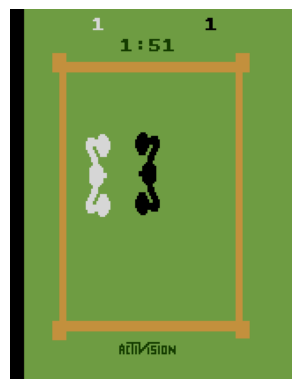